> Add tools 공식 문서: <https://langchain-ai.github.io/langgraph/tutorials/get-started/2-add-tools/>

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [2]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph.message import add_messages

# 상태 정의
class State(TypedDict):	
    messages: Annotated[list[str], add_messages]

In [3]:
from langgraph.graph import StateGraph

# 그래프 구성
graph_builder = StateGraph(State)

In [5]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

In [6]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "부산"})

'Asia/Seoul (부산) 현재시각 2025-09-18 11:11:17'

In [7]:
query = "2025년 KT 소액결제 사건의 원인은?"

In [8]:
tools[1].invoke({"query": query, "search_period": "m"})


-------- WEB SEARCH --------
2025년 KT 소액결제 사건의 원인은?
m
1. snippet: 2 days ago · 2025년 런던 사우스엔드공항 항공기 추락 사고가 일어났다. KBO 리그 키움 히어로즈 의 홍원기 와 고형욱 이 성적 부진 끝에 경질되었다., title: 2025 년 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/2025년
2. snippet: 2 days ago · September 20 – The Intervision 2025 is scheduled to be held in Moscow, Russia. [230] September 23 – The confirmation of charges for alleged crimes against humanity …, title: 2025 - Wikipedia, link: https://en.wikipedia.org/wiki/2025
3. snippet: 1 week ago - 왜 KT만 털렸나 무단 소액결제 사건 의문점 3가지 KT는 11일 불법 초소형 기지국을 통해 일부 고객의 국제이동가입자식별정보IMSI 정보가 유출된 것을 확인하고 이를 개인정보보호위원회에 신고했다고 밝혔다., title: Chosun Daily 왜 KT만 털렸나… ‘무단 소액결제’ 사건 의문점 3가지, link: https://www.chosun.com/economy/tech_it/2025/09/11/P6IGLCLDPFFARKYDTBAPSIHFYA/
4. snippet: 1 week ago - KT 소액결제 피해 사건의 원인이 ‘ 불법 기지국 ’이라는 정황이 나왔다. 해커들이 불법 기지국 을 설치해 이용자들의 통신 정보를 탈취했을 가능성이 제기된 것으로, 국내에선 발생한 적 없는 사건이다.KT는 지난 8일 ..., title: MediaToday ‘KT 소액결제 사건’ 원인은 불법 기지국? “서버 전수조사해야”, link: https://www.m

'snippet: 2 days ago · 2025년 런던 사우스엔드공항 항공기 추락 사고가 일어났다. KBO 리그 키움 히어로즈 의 홍원기 와 고형욱 이 성적 부진 끝에 경질되었다., title: 2025 년 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/2025년;\nsnippet: 2 days ago · September 20 – The Intervision 2025 is scheduled to be held in Moscow, Russia. [230] September 23 – The confirmation of charges for alleged crimes against humanity …, title: 2025 - Wikipedia, link: https://en.wikipedia.org/wiki/2025;\nsnippet: 1 week ago - 왜 KT만 털렸나 무단 소액결제 사건 의문점 3가지 KT는 11일 불법 초소형 기지국을 통해 일부 고객의 국제이동가입자식별정보IMSI 정보가 유출된 것을 확인하고 이를 개인정보보호위원회에 신고했다고 밝혔다., title: Chosun Daily 왜 KT만 털렸나… ‘무단 소액결제’ 사건 의문점 3가지, link: https://www.chosun.com/economy/tech_it/2025/09/11/P6IGLCLDPFFARKYDTBAPSIHFYA/;\nsnippet: 1 week ago - KT 소액결제 피해 사건의 원인이 ‘ 불법 기지국 ’이라는 정황이 나왔다. 해커들이 불법 기지국 을 설치해 이용자들의 통신 정보를 탈취했을 가능성이 제기된 것으로, 국내에선 발생한 적 없는 사건이다.KT는 지난 8일 ..., title: MediaToday ‘KT 소액결제 사건’ 원인은 불법 기지국? “서버 전수조사해야”, link: https://www.mediatoday.co.kr/news/articleView.html?idxno=328721'

In [9]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x000002221419FB00>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x000002221419EB60>


In [10]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [11]:
tools

[StructuredTool(name='get_current_time', description='현재 시각을 반환하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_current_time'>, func=<function get_current_time at 0x000002221419FB00>),
 StructuredTool(name='get_web_search', description='웹 검색을 수행하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_web_search'>, func=<function get_web_search at 0x000002221419EB60>)]

In [12]:
from pprint import pprint

# * 딕셔너리 컴프리헨션(Dictionary Comprehension)
# - 키(Key): tool.name은 현재 순회 중인 StructuredTool 객체의 name 속성 값을 추출하여 딕셔너리의 키로 사용한다.
# - 값(Value): tool은 현재 순회 중인 StructuredTool 객체 자체를 딕셔너리의 값으로 사용한다.
pprint({tool.name: tool for tool in tools})

{'get_current_time': StructuredTool(name='get_current_time', description='현재 시각을 반환하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_current_time'>, func=<function get_current_time at 0x000002221419FB00>),
 'get_web_search': StructuredTool(name='get_web_search', description='웹 검색을 수행하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_web_search'>, func=<function get_web_search at 0x000002221419EB60>)}


In [13]:
# * 왈러스(walrus) 연산자
# - 바다코끼리 닮아서 붙여진 이름
# - Python 3.8부터 도입된 문법
# - 일반적인 할당 연산자 (=)가 문(statement)인 반면, 왈러스 연산자는 식(expression)
# - 변수에 값을 할당하면서 동시에 그 값에 대한 참/거짓을 판별
dic = {"messages": ["a", "b"]}
if var := dic.get("messages"):
    print(var)

['a', 'b']


In [21]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    """

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools} # 딕셔너리 컴프리헨션(Dictionary Comprehension)

    def __call__(self, inputs: dict):
        # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
        if messages := inputs.get("messages", []): # 왈러스(walrus) 연산자 사용
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

In [ ]:
# * Case1
tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [14]:
# * Case2
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [15]:
from langgraph.graph import StateGraph, START, END

def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 END로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
        
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [16]:
graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")

In [17]:
graph = graph_builder.compile()

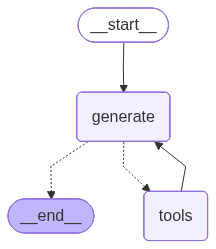

In [18]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [19]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 부산 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

지금 부산은 2025년 9월 18일 11시 12분 23초입니다.


In [20]:
gathered

AIMessageChunk(content='지금 부산은 2025년 9월 18일 11시 12분 23초입니다.\n', additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}'}}, response_metadata={'finish_reason': 'STOPSTOP', 'model_name': 'gemini-2.0-flashgemini-2.0-flash', 'safety_ratings': []}, id='run--5f1c1432-e4a1-4a5f-893f-ab8436ddfd0c', tool_calls=[{'name': 'get_current_time', 'args': {'location': '부산', 'timezone': 'Asia/Seoul'}, 'id': '4d003487-998d-4c2c-ada8-761c44e08977', 'type': 'tool_call'}], usage_metadata={'input_tokens': 152, 'output_tokens': 45, 'total_tokens': 254, 'input_token_details': {'cache_read': 0}}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}', 'id': '4d003487-998d-4c2c-ada8-761c44e08977', 'index': None, 'type': 'tool_call_chunk'}])

In [21]:
from langchain_core.messages import AIMessageChunk, SystemMessage

inputs = [
    SystemMessage(content=f"""
        너는 신문기자이다. 
        최근 {query}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.
    """),
    HumanMessage(content="""
        - 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
        - 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
        - 검색할 리스트를 토대로 재검색을 한다. 
        - 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
        - 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 
        
        더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
        제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.
    """)
]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        # print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg


-------- WEB SEARCH --------
2025년 KT 소액결제
3개월
1. snippet: Sep 11, 2025 · 2025년 8월 수도권에서 발생한 KT 소액결제 해킹 사건은 불법 초소형 기지국을 통한 역대급 해킹 피해 사례입니다. 피해 현황, 해킹 원인, KT 및 정부 대응, 보상 절차와 예방법까지 한눈에 정리했습니다. 2025년 8월 말부터 수도권 일부 지역을 중심으로 KT 및 KT 망을 사용하는 알뜰폰 고객들에게 휴대폰 ..., title: KT 소액결제 해킹 사건 정리 (2025) – 피해 현황·원인·보상 절차 완벽..., link: https://reasonablegift.tistory.com/175
2. snippet: 2 hours ago · 8월 5일 첫 발생 후 갈수록 늘어 KT “사전 확인·조치 못 해 송구”, KT 무단 소액결제 사태가 최소 지난달 초부터 이어져 온 것으로 나타났다. 초기에 ..., title: KT 소액결제, 한 달 전부터 ‘이상 신호’ | 서울신문, link: https://www.seoul.co.kr/news/economy/industry/2025/09/18/20250918016002
3. snippet: Sep 7, 2025 · 1. 개요 [편집] 2025년 8월 말 수도권 지역에서 KT 통신사 고객의 휴대전화 무단 소액결제 피해가 발생한 사건., title: KT 소액결제 해킹 사건 - 나무위키, link: https://namu.wiki/w/KT+소액결제+해킹+사건
4. snippet: 6 days ago · K씨는 4 년 전 일을 최근 KT 무단 소액결제 건으로 상기하고 과학기술정보통신부, 방송통신위원회 등 유관 부처에 재문의했다. 인공지능이 자동으로 줄인 '세 줄 요약' 기술을 사용합니다. 전체 내용을 이해하기 위해서는 기사 본문과 함께 읽어야 합니다., title: KT 해킹 사태…소액결제 허점 드러났다 | 연합뉴스, link: https://www.yna.co.kr/view/AKR2025

In [22]:
gathered

AIMessageChunk(content='알겠습니다. 2025년 KT 소액결제 사건에 대한 심층 분석 기사를 작성하기 위해 다음과 같은 단계를 따르겠습니다.\n\n**1단계: 최근 이슈 검색 및 주제 선정**\n\n먼저, 최근 이슈를 검색하여 사람들이 가장 관심 있어 할 만한 주제를 선정하고, 선정 이유를 설명하겠습니다.\n\n최근 KT 소액결제 해킹 사건이 큰 이슈이며, 특히 \'해킹 원인\'에 대한 관심이 높은 것으로 판단됩니다. 이는 유사 사건 재발 방지를 위해 근본적인 원인 규명이 중요하기 때문입니다.\n\n**기사 목차**\n\n1.  **머리말:** 2025년 KT 소액결제 해킹 사건 개요 및 사회적 파장\n2.  **사건의 재구성:**\n    *   피해 규모 및 발생 추이 상세 분석\n    *   소액결제 시스템의 허점: 인증, 보안, 관리 취약점 심층 분석\n    *   KT의 초기 대응 문제점: 인지 지연, 미흡한 공지, 안일한 대처\n3.  **불법 초소형 기지국 심층 분석:**\n    *   원리: 불법 초소형 기지국 작동 방식 상세 분석\n    *   기술적 허점: 기지국 탐지 및 차단 기술의 한계\n    *   법적 문제: 불법 기지국 설치 및 운영 처벌 미비\n4.  **KT의 책임과 과제:**\n    *   사고 원인 규명 및 재발 방지 대책\n    *   피해 고객 보상 및 신뢰 회복 노력\n    *   KT의 보안 시스템 강화 방안\n5.  **정부 및 관련 기관의 역할:**\n    *   사이버 보안 관련 법규 및 규제 강화 필요성\n    *   통신사 보안 시스템 관리 감독 강화\n    *   피해 예방 및 대응 위한 정부 지원 확대\n6.  **결론:** KT 소액결제 해킹 사건의 교훈 및 향후 과제\n\n**추가 검색 내용**\n\n1.  2025년 KT 소액결제 해킹 사건 피해자 인터뷰\n2.  불법 초소형 기지국 탐지 및 차단 기술 현황\n3.  국내외 통신사 개인 정보 유출 및 해킹 사례\n4

In [23]:
print(gathered.content)

알겠습니다. 2025년 KT 소액결제 사건에 대한 심층 분석 기사를 작성하기 위해 다음과 같은 단계를 따르겠습니다.

**1단계: 최근 이슈 검색 및 주제 선정**

먼저, 최근 이슈를 검색하여 사람들이 가장 관심 있어 할 만한 주제를 선정하고, 선정 이유를 설명하겠습니다.

최근 KT 소액결제 해킹 사건이 큰 이슈이며, 특히 '해킹 원인'에 대한 관심이 높은 것으로 판단됩니다. 이는 유사 사건 재발 방지를 위해 근본적인 원인 규명이 중요하기 때문입니다.

**기사 목차**

1.  **머리말:** 2025년 KT 소액결제 해킹 사건 개요 및 사회적 파장
2.  **사건의 재구성:**
    *   피해 규모 및 발생 추이 상세 분석
    *   소액결제 시스템의 허점: 인증, 보안, 관리 취약점 심층 분석
    *   KT의 초기 대응 문제점: 인지 지연, 미흡한 공지, 안일한 대처
3.  **불법 초소형 기지국 심층 분석:**
    *   원리: 불법 초소형 기지국 작동 방식 상세 분석
    *   기술적 허점: 기지국 탐지 및 차단 기술의 한계
    *   법적 문제: 불법 기지국 설치 및 운영 처벌 미비
4.  **KT의 책임과 과제:**
    *   사고 원인 규명 및 재발 방지 대책
    *   피해 고객 보상 및 신뢰 회복 노력
    *   KT의 보안 시스템 강화 방안
5.  **정부 및 관련 기관의 역할:**
    *   사이버 보안 관련 법규 및 규제 강화 필요성
    *   통신사 보안 시스템 관리 감독 강화
    *   피해 예방 및 대응 위한 정부 지원 확대
6.  **결론:** KT 소액결제 해킹 사건의 교훈 및 향후 과제

**추가 검색 내용**

1.  2025년 KT 소액결제 해킹 사건 피해자 인터뷰
2.  불법 초소형 기지국 탐지 및 차단 기술 현황
3.  국내외 통신사 개인 정보 유출 및 해킹 사례
4.  통신사 보안 투자 현황 및 효과 분석
5.  사이버 보안 관련 법규 및 규제 비교 (국내 vs 해외)
